In [1]:
import xarray as xr
import cartopy
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
from matplotlib.collections import LineCollection

### Data

In [2]:
ds = xr.open_dataset("/work/bk1450/b383184/Amazon/Atlantic/data/tracks_4567/Parcels_run_4567_2022-06-05.zarr")
ds

<xarray.Dataset> Size: 148MB
Dimensions:     (trajectory: 10000, obs: 740)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 733 734 735 736 737 738 739
  * trajectory  (trajectory) int64 80kB 0 1 2 3 4 5 ... 9995 9996 9997 9998 9999
Data variables:
    lat         (trajectory, obs) float32 30MB ...
    lon         (trajectory, obs) float32 30MB ...
    time        (trajectory, obs) datetime64[ns] 59MB ...
    z           (trajectory, obs) float32 30MB ...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [3]:
# accumulate points and colors
pts = []
cols = []
for i in range(100):
    xi = np.asarray(ds.lon[i]); yi = np.asarray(ds.lat[i]); zi = np.asarray(ds.z[i])
    m = np.isfinite(xi) & np.isfinite(yi) & np.isfinite(zi)
    if m.any():
        pts.append(np.column_stack([xi[m], yi[m]]))
        cols.append(zi[m])

pts = np.vstack(pts)     # shape (N, 2)
cols = np.concatenate(cols)  # shape (N,)

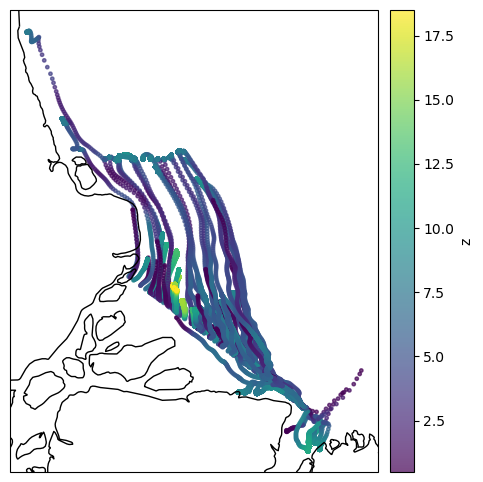

In [4]:
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
sc = ax.scatter(pts[:,0], pts[:,1], c=cols, cmap='viridis', s=6, alpha=0.7,
                transform=ccrs.PlateCarree())
ax.coastlines()
cbar = plt.colorbar(sc, ax=ax, pad=0.02); cbar.set_label('z')
plt.show()

### Xhist depth

In [3]:
from xhistogram.xarray import histogram

In [25]:
# ds.lat.min().compute().data[()]
ds.lat.min().compute().data[()]

np.float64(-0.9166609048843384)

In [27]:
# def calc_hist(ds):
#     return xhist(
#         ds.lon,
#         ds.lat,
#         bins=[lon_bins, lat_bins],
#         dim=["trajectory", ],
#         bin_dim_suffix=""
#     )


In [40]:
lon_min = ds.lon.min().compute().data[()]
lon_max = ds.lon.max().compute().data[()]

lat_min = ds.lat.min().compute().data[()]
lat_max = ds.lat.max().compute().data[()]
## [()]: indexes a 0-dim NumPy array to extract the Python scalar. Equivalent to .item(). For python scalar
lat_bins = np.linspace(lat_min, lat_max, 30)
lon_bins = np.linspace(lon_min, lon_max, 30)

histogram(ds.lon.compute(),
          ds.lat.compute(),
          bins=[lon_bins,lat_bins],
          dim=["trajectory", ],
          bin_dim_suffix="",
         )

<xarray.DataArray 'histogram_lon_lat' (obs: 740, lon: 29, lat: 29)> Size: 5MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 1, 0, ..., 0, 0, 0]]], shape=(740, 29, 29))
Coordinates:
  * obs      (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 732 733 734 735 736 737 738 739
  * lon      (lon) float64 232B -64.99 -63.03 -61.07 ... -14.01 -12.05 -10.09
  * lat      (lat) float64 232B -0.5977 0.04028 0.6782 ... 15.99 16.63 17.27

(array([1.53832e+05, 2.14000e+02, 3.67000e+02, 1.15000e+02, 6.00000e+00,
        1.80000e+01, 1.44000e+02, 4.00000e+01, 3.00000e+00, 5.00000e+00]),
 array([    0. ,  1659.5,  3319. ,  4978.5,  6638. ,  8297.5,  9957. ,
        11616.5, 13276. , 14935.5, 16595. ]),
 <BarContainer object of 10 artists>)

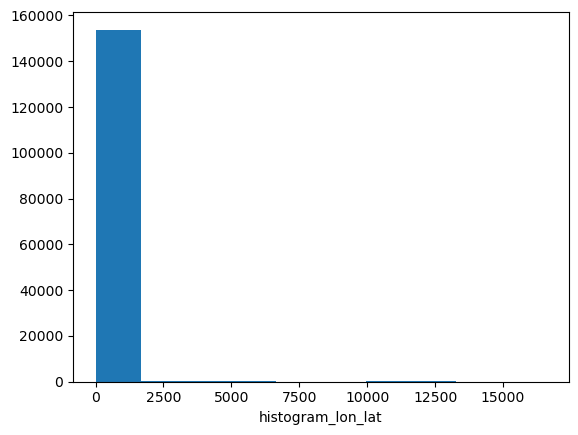

In [89]:
hist = histogram(ds.lon.compute(),
          ds.lat.compute(),
          bins=[lon_bins,lat_bins],
          dim=["trajectory", ],
          bin_dim_suffix="",
         ).isel(obs=slice(1, None)).coarsen(obs=4, boundary="trim").sum()
hist.plot()

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


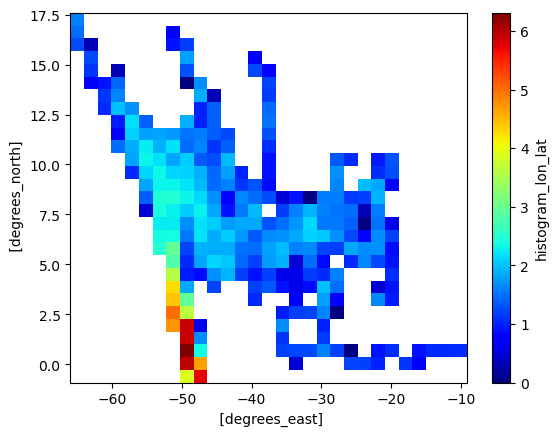

In [90]:
np.log10(hist.sum("obs")).plot(
            x="lon", y="lat", 
            add_colorbar=True, cmap='jet'
        )

In [91]:
depth_hist = histogram(
        ds.lon, ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory"],              # reduce over particles only
        weights=ds.z,                # sum of depth in each bin
        bin_dim_suffix=""
    )
depth_hist = depth_hist.isel(obs=slice(1, None)).coarsen(obs=4, boundary="trim").sum()
depth_hist

<xarray.DataArray 'histogram_lon_lat' (obs: 184, lon: 29, lat: 29)> Size: 1MB
array([[[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       [[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
...
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        , 362.95930481, ...,   0.        ,
           0.        ,   0.        ]],

       [[  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        ...,
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        , 364.24835968, ...,   0.        ,
           0.        ,   0.        ]]], shape=(184, 29, 29))
Coordinates:
  * obs      (obs) float64 1kB 2.5 6.5 10.5 14.5 ... 722.5 726.5 730.5 734.5
  * lon      (lon) float64 232B -64.99 -63.03 -61.07 ... -14.01 -12.05 -10.09
  * lat      (lat) float64 232B -0.5977 0.04028 0.6782 ... 15.99 16.63 17.27

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


Text(0.5, 1.0, 'Just adding Depths')

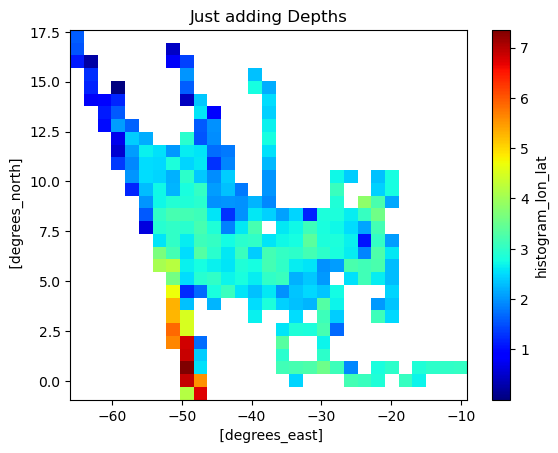

In [92]:
np.log10(depth_hist.sum("obs")).plot(
            x="lon", y="lat", 
            add_colorbar=True, cmap='jet'
        )
plt.title('Just adding Depths')

In [93]:
zz = depth_hist/hist
zz 

# zz = np.divide(depth_hist, hist, out=np.full_like(depth_hist, np.nan), where=hist != 0)
# zz

<xarray.DataArray 'histogram_lon_lat' (obs: 184, lon: 29, lat: 29)> Size: 1MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan, 90.7398262 , ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan, 91.06208992, ...,         nan,
                 nan,         nan]]], shape=(184, 29, 29))
Coordinates:
  * obs      (obs) float64 1kB 2.5 6.5 10.5 14.5 ... 722.5 726.5 730.5 734.5
  * lon      (lon) float64 232B -64.99 -63.03 -61.07 ... -14.01 -12.05 -10.09
  * lat      (lat) float64 232B -0.5977 0.04028 0.6782 ... 15.99 16.63 17.27

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)


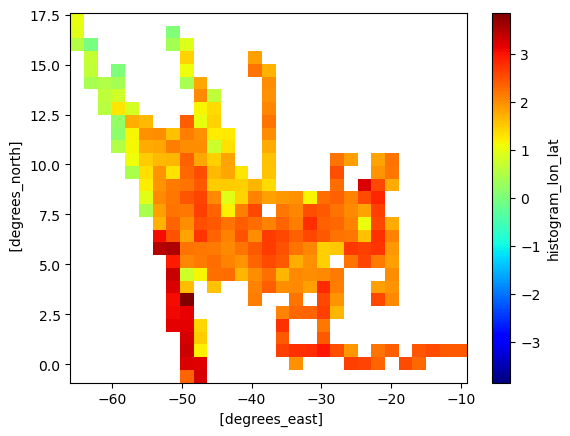

In [94]:
np.log10(zz.sum("obs")).plot(
            x="lon", y="lat", 
            add_colorbar=True, cmap='jet'
        )

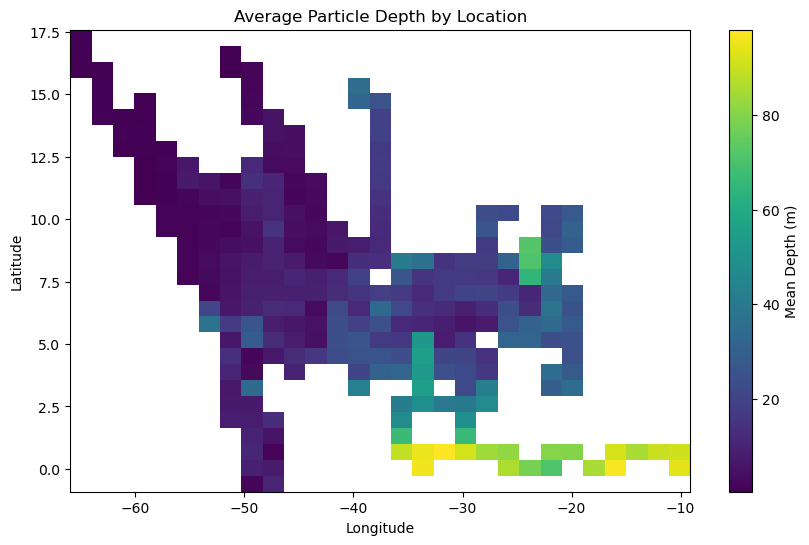

In [85]:
# Histograma ponderado por profundidad
z_sum, xedges, yedges = np.histogram2d(
    ds.lat.data.flatten(), ds.lon.data.flatten(),  # <- orden: lat, lon = y, x
    bins=(lat_bins, lon_bins),
    weights=ds.z.data.flatten()
)

# Conteo de partículas por celda
counts, _, _ = np.histogram2d(
    ds.lat.data.flatten(), ds.lon.data.flatten(),
    bins=(lat_bins, lon_bins)
)

# Calcular profundidad promedio (evitando división por 0)
z_avg = np.divide(z_sum, counts, out=np.full_like(z_sum, np.nan), where=counts != 0)

plt.figure(figsize=(10, 6))
plt.pcolormesh(yedges, xedges, z_avg, cmap="viridis")  # y: lon, x: lat
plt.colorbar(label="Mean Depth (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average Particle Depth by Location")
plt.show()

### Another method using volume

In [98]:
from xhistogram.xarray import histogram as xhist
import xarray as xr
import numpy as np
import cmocean as cm

# bins (same as your np.hist2d)
lon_bins = np.linspace(lon_min, lon_max, 30)
lat_bins = np.linspace(lat_min, lat_max, 30)

# joint mask
m = np.isfinite(ds.lon) & np.isfinite(ds.lat) & np.isfinite(ds.z)
lon_m = ds.lon.where(m)
lat_m = ds.lat.where(m)
z_m   = ds.z.where(m)            # keep NaN outside mask
z_w   = z_m.fillna(0.0)          # weights must be NaN-free for xhist
zz = xr.where(count5 > 0, depth_sum5 / count5, np.nan).rename("mean_depth")

depth_sum = xhist(
    lon_m, lat_m,
    bins=[lon_bins, lat_bins],
    dim=["trajectory"],    # reduce over particles only
    weights=z_w,           # sum of depth in bin
    bin_dim_suffix=""      # names 'lon', 'lat'
).rename("depth_sum")

count = xhist(
    lon_m, lat_m,
    bins=[lon_bins, lat_bins],
    dim=["trajectory"],
    bin_dim_suffix=""
).rename("count")

# Example: skip first obs and aggregate over 5 days with 4 steps/day
depth_sum5 = depth_sum.isel(obs=slice(1, None)).coarsen(obs=4*5, boundary="trim").sum()
count5     = count    .isel(obs=slice(1, None)).coarsen(obs=4*5, boundary="trim").sum()

# Mean depth per bin (like z_sum/counts in np.hist2d)
zz = xr.where(count5 > 0, depth_sum5 / count5, np.nan).rename("mean_depth")



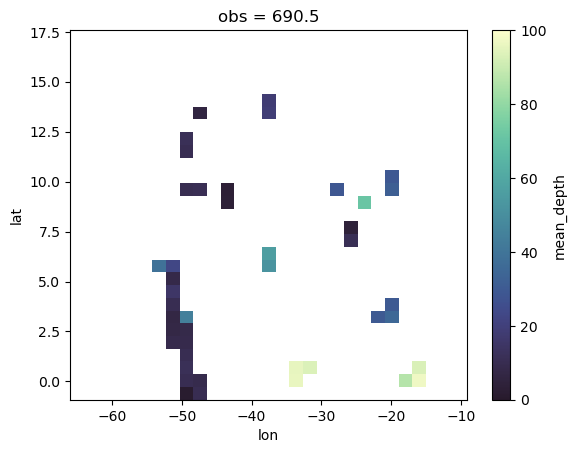

In [114]:
zz0 = zz.isel(obs=34)  # pick one window for comparison
zz0.plot(x='lon', y='lat', cmap=cm.cm.deep_r, vmin=0, vmax=100)
plt.show()

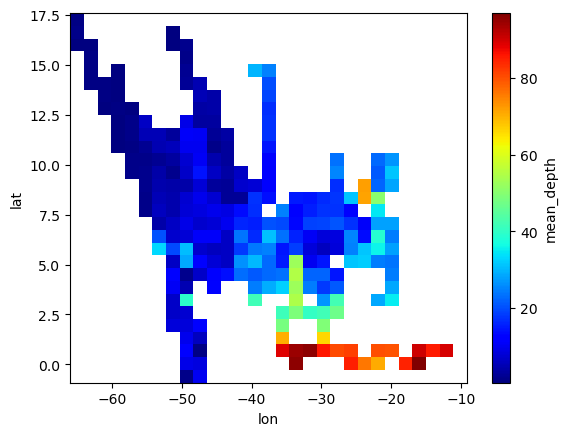

In [115]:
zz.mean("obs").plot(
            x="lon", y="lat", 
            add_colorbar=True, cmap='jet'
        )

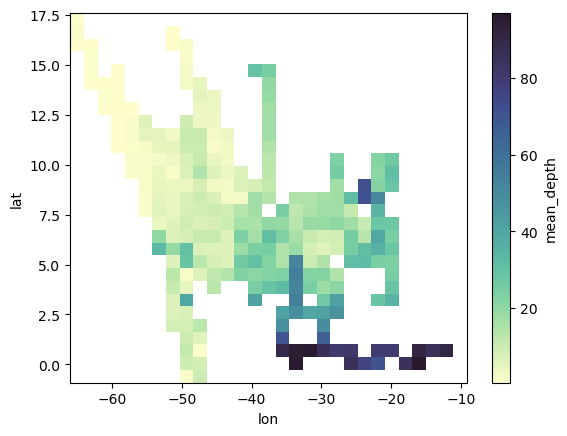

In [128]:
zz.mean("obs").plot(
            x="lon", y="lat", 
            add_colorbar=True, cmap=cm.cm.deep
        )

### Hist_depth load

In [116]:
hist_depth = xr.open_dataset("_hist_5day_depth.nc").compute().depth_mean
hist_depth

<xarray.DataArray 'depth_mean' (obs: 37, lon: 29, lat: 29, start_year: 4,
                                start_month: 12, start_day: 6)> Size: 72MB
array([[[[[[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           ...,
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
...
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]],

          [[        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           ...,
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan],
           [        nan,         nan,         nan,         nan,
                    nan,         nan]]]]]], shape=(37, 29, 29, 4, 12, 6))
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * start_day    (start_day) float64 48B 5.0 10.0 15.0 20.0 25.0 30.0
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float32 116B -87.67 -84.59 -81.51 ... -4.615 -1.539
  * lat          (lat) float32 116B -3.942 -2.754 -1.566 ... 26.95 28.14 29.33

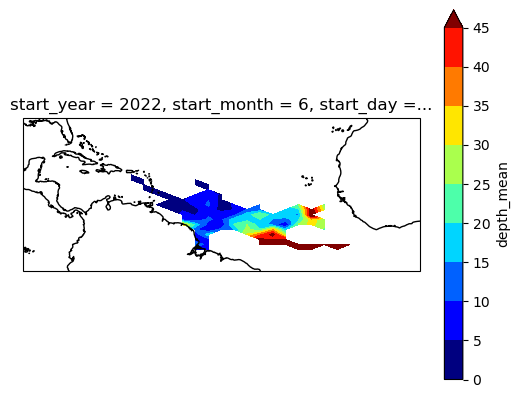

In [124]:
da = hist_depth.sel(start_year=2022, start_month=6, start_day=5).mean("obs")
da = da.where(da!=0)
# da.plot(x="lon", y="lat",transform=cartopy.crs.PlateCarree(),
#         add_colorbar=False,cmap='jet_r',subplot_kw={"projection": cartopy.crs.PlateCarree()})

ax = plt.axes(projection=cartopy.crs.PlateCarree())
levels = np.arange(0, 50, 5)  # 0,50,100,...,500

da.plot.contourf(
    x="lon", y="lat",
    ax=ax, transform=cartopy.crs.PlateCarree(),
    cmap='jet', add_colorbar=True,
    levels=levels
)
ax.coastlines()

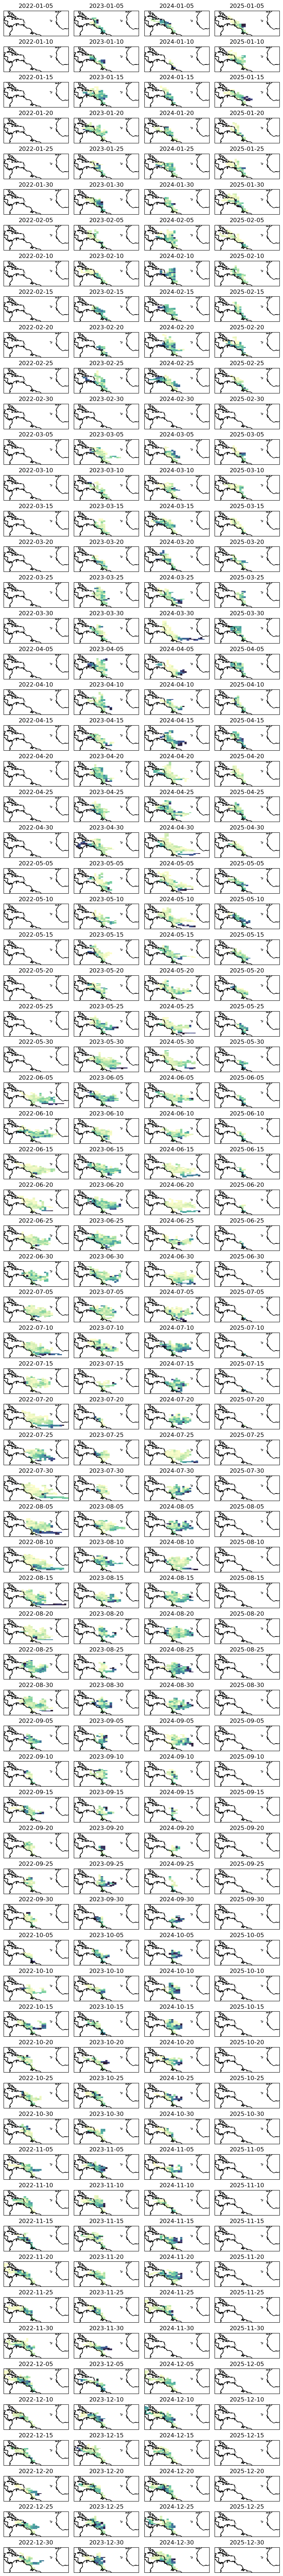

In [126]:
# Get unique sorted values
unique_years = sorted(np.unique(hist_depth.start_year.data))
unique_months = sorted(np.unique(hist_depth.start_month.data))
unique_days = sorted(np.unique(hist_depth.start_day.data))  # e.g., [1,6,11,16,21] or whatever your 5 days are

num_years = len(unique_years)
num_months = len(unique_months)
num_days = len(unique_days)  # Should be 5

# Create subplots: rows = months * days (grouped by month), columns = years
fig, ax = plt.subplots(
    num_months * num_days, num_years,
    figsize=(num_years * 2, num_months * num_days),  # Adjust size dynamically
    subplot_kw={"projection": cartopy.crs.PlateCarree()},
)

np.seterr(divide='ignore')  # Don't warn on np.log10 on invalid or 0 data

for nyr, syr in enumerate(unique_years):
    for nmon, smon in enumerate(unique_months):
        for nday, sday in enumerate(unique_days):
            # Calculate row index: group days within each month
            row = nmon * num_days + nday
            _ax = ax[row, nyr]
            
            # Select and plot (assuming 'obs' is the dimension to sum over)
            data = hist_depth.sel(start_year=syr, start_month=smon, start_day=sday).mean("obs")
            data.plot(
                x="lon", y="lat",
                transform=cartopy.crs.PlateCarree(), ax=_ax,
                add_colorbar=False,cmap=cm.cm.deep
            ) ## change here the log10 by adding nan to 0s
            _ax.set_title(f"{int(syr):04d}-{int(smon):02d}-{int(sday):02d}")
            _ax.coastlines()

fig.tight_layout()
# fig.savefig('particles_5days_depth.pdf', dpi=300, bbox_inches='tight')